# 💡 Entrenamiento + Evaluación LightGBM — 4 herramientas

**Versión básica**, sin tuneo de hiperparámetros (Optuna queda para una iteración posterior).

## Flujo

Misma estructura que `def_entrenar_evaluar_4herramientas.ipynb` (RF). La función `cargar_datos` es idéntica, así la comparativa RF vs XGBoost es 1:1: mismos datos, mismas columnas filtradas, mismo split.

Para cada herramienta:
1. Cargar las 8 clases con `cargar_datos(usar_solo_columnas_comunes=True, eliminar_sospechosas=True)`.
2. Codificar `y` con `LabelEncoder` (por consistencia con XGBoost; LightGBM tampoco acepta strings).
3. `train_test_split` 80/20 estratificado, `random_state=42`.
4. Entrenar `LGBMClassifier(n_estimators=100)`.
5. Predecir y medir tiempos.

## Salidas
- Tabla comparativa con accuracy, F1, recall, precision macro, **tiempos** (train, pred, μs/muestra).
- **Matriz de confusión por herramienta** (grid 2×2 con heatmaps).
- Top features por herramienta.

**Run All y listo.**

In [1]:
# ============================================================
# CELDA 0 — IMPORTS Y CONFIGURACIÓN
# ============================================================
import pandas as pd
import numpy as np
import time
import gc
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                              f1_score, confusion_matrix)

import warnings
warnings.filterwarnings('ignore')

BASE_IN = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/BaseDatos')

CLASES = ['BenignTraffic', 'DictionaryBruteForce', 'Recon', 'Mirai',
          'Spoofing', 'DoS', 'DDoS', 'Web']
HERRAMIENTAS = ['CIC', 'Nemea', 'Tstat', 'Tshark']

SEED = 42

print(f'Carpeta de entrada: {BASE_IN}')
print(f'Clases: {len(CLASES)}')
print(f'Herramientas: {HERRAMIENTAS}')

Carpeta de entrada: /home/miguel/Escritorio/TFM/TFM_Miguel/BaseDatos
Clases: 8
Herramientas: ['CIC', 'Nemea', 'Tstat', 'Tshark']


In [2]:
# ============================================================
# CELDA 1 — FUNCIÓN cargar_datos (idéntica a la del notebook RF)
# Devuelve (X, y) listos para entrenar, con las mismas reglas de
# filtrado: solo columnas comunes y eliminando sospechosas de fuga.
# ============================================================

def cargar_datos(herramienta, usar_solo_columnas_comunes=True, eliminar_sospechosas=True):
    dfs_por_clase = {}
    columnas_por_clase = {}

    for clase in CLASES:
        ruta = BASE_IN / clase / f'{herramienta}.csv'
        df_tmp = pd.read_csv(ruta, low_memory=False)
        dfs_por_clase[clase] = df_tmp
        columnas_por_clase[clase] = list(df_tmp.columns)

    print('\n' + '='*80)
    print(f'CARGA — {herramienta}')
    print('='*80)

    for clase in CLASES:
        df_tmp = dfs_por_clase[clase]
        print(f'{clase:<25} {df_tmp.shape[0]:,} filas x {df_tmp.shape[1]} columnas')

    conjuntos = [set(columnas_por_clase[clase]) for clase in CLASES]
    columnas_comunes_set = set.intersection(*conjuntos)
    columnas_union_set   = set.union(*conjuntos)

    if usar_solo_columnas_comunes:
        columnas_base = [c for c in columnas_por_clase[CLASES[0]] if c in columnas_comunes_set]
    else:
        columnas_base = sorted(columnas_union_set)

    patrones_fuga = [
        'label', 'etiqueta', 'class', 'attack', 'category', 'subtipo',
        'archivo', 'file', 'pcap',
        'flow_id', 'macaddr', 'mac', 'src_mac', 'dst_mac',
        'fqdn', 'sni', 'scn', 'dns_rslv', 'tls_sesid', 'npnalpn', 'alpn',
        'first_abs', 'req_tm', 'res_tm', 'handshaket', 'appdatat',
    ]

    columnas_id_exactas = {'id', 'ID', 'Flow ID', 'FLOW_ID', 'flow_id', 'uint64 FLOW_ID'}

    columnas_temporales_peligrosas_exactas = {
        'time* DBI_BRST_TIME_START', 'time* DBI_BRST_TIME_STOP',
        'time* SBI_BRST_TIME_START', 'time* SBI_BRST_TIME_STOP',
        'last', 'req_tm', 'res_tm', 's_first_abs',
        'c_first', 's_first', 'c_last', 's_last',
        'c_first_ack', 's_first_ack',
        'c_last_handshakeT', 's_last_handshakeT',
        'c_appdataT', 's_appdataT',
    }

    columnas_sospechosas = []
    if eliminar_sospechosas:
        for col in columnas_base:
            col_lower = col.lower()
            es_sospechosa_por_patron = any(p in col_lower for p in patrones_fuga)
            es_id = col in columnas_id_exactas or col_lower in columnas_id_exactas
            es_temporal_peligrosa = (
                col in columnas_temporales_peligrosas_exactas
                or col_lower in columnas_temporales_peligrosas_exactas
                or col_lower.startswith('time_ppi_pkt_times_')
            )
            if es_sospechosa_por_patron or es_id or es_temporal_peligrosa:
                columnas_sospechosas.append(col)

    if columnas_sospechosas:
        print(f'\n[{herramienta}] Columnas eliminadas por posible fuga directa: {len(columnas_sospechosas)}')

    columnas_finales = [c for c in columnas_base if c not in columnas_sospechosas]
    print(f'[{herramienta}] Columnas finales antes de concatenar: {len(columnas_finales)}')

    dfs = []
    for clase in CLASES:
        df_tmp = dfs_por_clase[clase][columnas_finales].copy()
        df_tmp['Label_Modelo'] = clase
        dfs.append(df_tmp)

    df = pd.concat(dfs, ignore_index=True, sort=False)
    y = df['Label_Modelo']
    X = df.drop(columns=['Label_Modelo'])

    cols_obj = X.select_dtypes(include=['object']).columns.tolist()
    if cols_obj:
        print(f'[{herramienta}] Columnas object codificadas con LabelEncoder: {len(cols_obj)}')
    for col in cols_obj:
        X[col] = X[col].fillna('__missing__').astype(str)
        X[col] = LabelEncoder().fit_transform(X[col])

    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

    cols_constantes = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
    if cols_constantes:
        print(f'[{herramienta}] Columnas constantes eliminadas tras concatenar: {len(cols_constantes)}')
        X = X.drop(columns=cols_constantes)

    print(f'[{herramienta}] Shape final X: {X.shape}')
    return X, y

In [3]:
# ============================================================
# CELDA 2 — FUNCIÓN: entrenar XGBoost básico y evaluar
# Devuelve métricas (con tiempos), matriz de confusión e importancias
# ============================================================

def entrenar_y_evaluar_lgbm(X, y, herramienta):
    # 1) Codificar y (XGBoost NO acepta etiquetas string)
    le_y = LabelEncoder()
    y_enc = le_y.fit_transform(y)
    nombres_clase = list(le_y.classes_)

    # 2) Split estratificado 80/20, mismo seed que en RF para comparabilidad
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.2, random_state=SEED, stratify=y_enc
    )

    # 3) LGBM básico
    lgbm = LGBMClassifier(
        n_estimators=100,
        random_state=SEED,
        n_jobs=-1,
        verbose=-1,
    )

    t0 = time.time()
    lgbm.fit(X_train, y_train)
    t_train = time.time() - t0

    t0 = time.time()
    y_pred = lgbm.predict(X_test)
    t_pred = time.time() - t0

    n_test = len(X_test)
    metricas = {
        'Herramienta':       herramienta,
        'N features':        X.shape[1],
        'Accuracy':          accuracy_score(y_test, y_pred),
        'F1 macro':          f1_score(y_test, y_pred, average='macro'),
        'Recall macro':      recall_score(y_test, y_pred, average='macro'),
        'Precision macro':   precision_score(y_test, y_pred, average='macro'),
        'Tiempo train (s)':  t_train,
        'Tiempo pred (s)':   t_pred,
        'Pred us/muestra':   (t_pred / n_test) * 1e6,
    }

    # 4) Matriz de confusión (en el orden de CLASES si todas están presentes)
    etiquetas_idx = list(range(len(nombres_clase)))
    cm = confusion_matrix(y_test, y_pred, labels=etiquetas_idx)

    # 5) Importancias
    importancias = pd.DataFrame({
        'feature': X.columns,
        'importance': lgbm.feature_importances_
    }).sort_values('importance', ascending=False)

    print(f'\n[{herramienta}] Top 15 features por importancia:')
    print(importancias.head(15).to_string(index=False))
    print(f'\n[{herramienta}] Accuracy: {metricas["Accuracy"]:.4f}  F1 macro: {metricas["F1 macro"]:.4f}')
    print(f'[{herramienta}] Tiempo train: {t_train:.2f}s | pred: {t_pred:.2f}s ({metricas["Pred us/muestra"]:.1f} us/muestra)')

    return metricas, cm, nombres_clase, importancias

In [4]:
# ============================================================
# CELDA 3 — BUCLE PRINCIPAL: las 4 herramientas
# ============================================================

resultados = []
matrices_dict = {}      # herramienta -> matriz de confusión
nombres_dict = {}       # herramienta -> lista de nombres de clase en orden
importancias_dict = {}  # herramienta -> DataFrame de importancias

for herr in HERRAMIENTAS:
    print('\n' + '#'*80)
    print(f'#  PROCESANDO {herr}')
    print('#'*80)

    X, y = cargar_datos(herr, usar_solo_columnas_comunes=True, eliminar_sospechosas=True)
    metricas, cm, nombres, imp = entrenar_y_evaluar_lgbm(X, y, herr)

    resultados.append(metricas)
    matrices_dict[herr] = cm
    nombres_dict[herr] = nombres
    importancias_dict[herr] = imp

    del X, y
    gc.collect()


################################################################################
#  PROCESANDO CIC
################################################################################

CARGA — CIC
BenignTraffic             3,481 filas x 71 columnas
DictionaryBruteForce      3,481 filas x 71 columnas
Recon                     3,481 filas x 71 columnas
Mirai                     3,481 filas x 71 columnas
Spoofing                  3,481 filas x 71 columnas
DoS                       3,481 filas x 71 columnas
DDoS                      3,481 filas x 71 columnas
Web                       3,481 filas x 71 columnas

[CIC] Columnas eliminadas por posible fuga directa: 1
[CIC] Columnas finales antes de concatenar: 70
[CIC] Columnas constantes eliminadas tras concatenar: 1
[CIC] Shape final X: (27848, 69)

[CIC] Top 15 features por importancia:
                   feature  importance
              Flow IAT Min        1784
              Flow Bytes/s        1544
             Flow Duration         865
   

In [5]:
# ============================================================
# CELDA 4 — TABLA COMPARATIVA FINAL
# ============================================================

df_res = pd.DataFrame(resultados)

print('='*110)
print('  TABLA COMPARATIVA — LightGBM básico (n_estimators=100)')
print('='*110)

df_show = df_res.copy()
for col in ['Accuracy', 'F1 macro', 'Recall macro', 'Precision macro']:
    df_show[col] = df_show[col].map(lambda v: f'{v:.4f}')
for col in ['Tiempo train (s)', 'Tiempo pred (s)']:
    df_show[col] = df_show[col].map(lambda v: f'{v:.2f}')
df_show['Pred us/muestra'] = df_show['Pred us/muestra'].map(lambda v: f'{v:.1f}')

print(df_show.to_string(index=False))

print('\n' + '='*110)
print('  REFERENCIA: Random Forest y XGBoost (mismo dataset, mismo split, mismas columnas)')
print('='*110)
print('  Herramienta   N feats  RF Acc   RF F1    XGB Acc  XGB F1')
print('  CIC                69   0.7106   0.7099   0.7425   0.7422')
print('  Nemea             148   0.5980   0.5829   0.5998   0.5846')
print('  Tstat              96   0.6346   0.6311   0.6289   0.6247')
print('  Tshark             50   0.7431   0.7434   0.7591   0.7584')

  TABLA COMPARATIVA — LightGBM básico (n_estimators=100)
Herramienta  N features Accuracy F1 macro Recall macro Precision macro Tiempo train (s) Tiempo pred (s) Pred us/muestra
        CIC          69   0.7429   0.7427       0.7429          0.7477           143.14            0.17            29.8
      Nemea         148   0.5993   0.5853       0.5992          0.6311            28.77            0.19            33.7
      Tstat          96   0.6320   0.6273       0.6319          0.6699            34.68            0.16            28.7
     Tshark          50   0.7535   0.7531       0.7535          0.7569            29.99            0.17            30.6

  REFERENCIA: Random Forest y XGBoost (mismo dataset, mismo split, mismas columnas)
  Herramienta   N feats  RF Acc   RF F1    XGB Acc  XGB F1
  CIC                69   0.7106   0.7099   0.7425   0.7422
  Nemea             148   0.5980   0.5829   0.5998   0.5846
  Tstat              96   0.6346   0.6311   0.6289   0.6247
  Tshark           

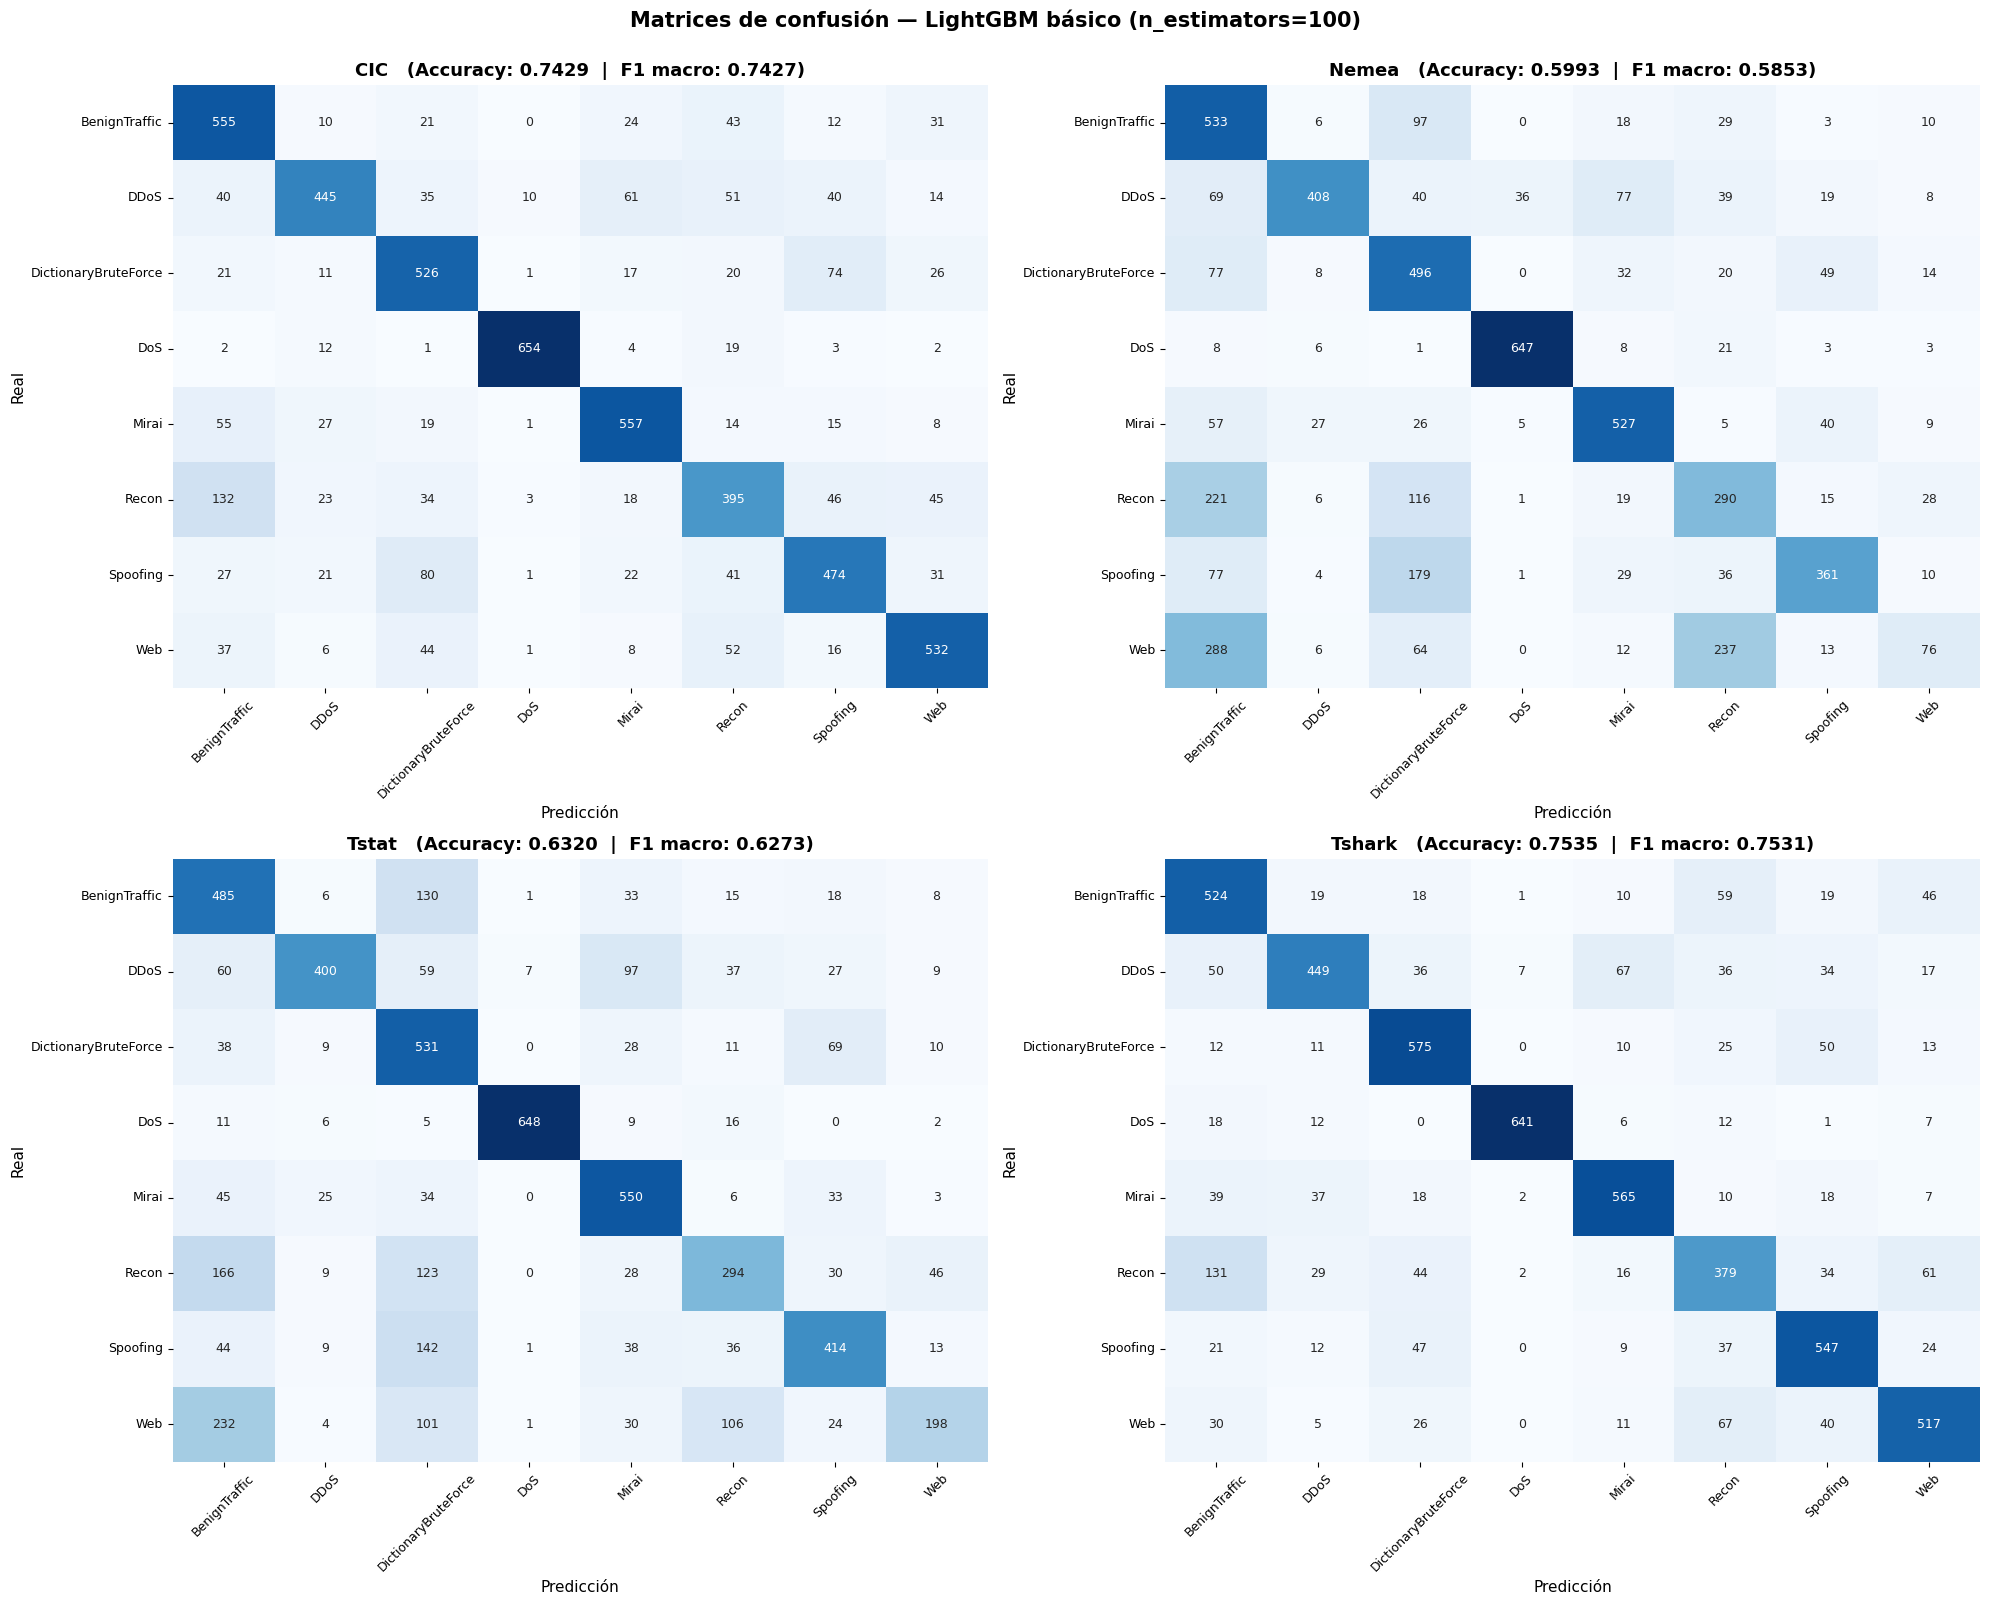

In [6]:
# ============================================================
# CELDA 5 — MATRICES DE CONFUSIÓN (grid 2×2)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for i, herr in enumerate(HERRAMIENTAS):
    cm = matrices_dict[herr]
    nombres = nombres_dict[herr]
    ax = axes[i]

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=nombres, yticklabels=nombres,
        ax=ax, cbar=False, square=False,
        annot_kws={'size': 9}
    )

    acc = next(r['Accuracy'] for r in resultados if r['Herramienta'] == herr)
    f1  = next(r['F1 macro'] for r in resultados if r['Herramienta'] == herr)
    ax.set_title(f'{herr}   (Accuracy: {acc:.4f}  |  F1 macro: {f1:.4f})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicción', fontsize=11)
    ax.set_ylabel('Real', fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.suptitle('Matrices de confusión — LightGBM básico (n_estimators=100)', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

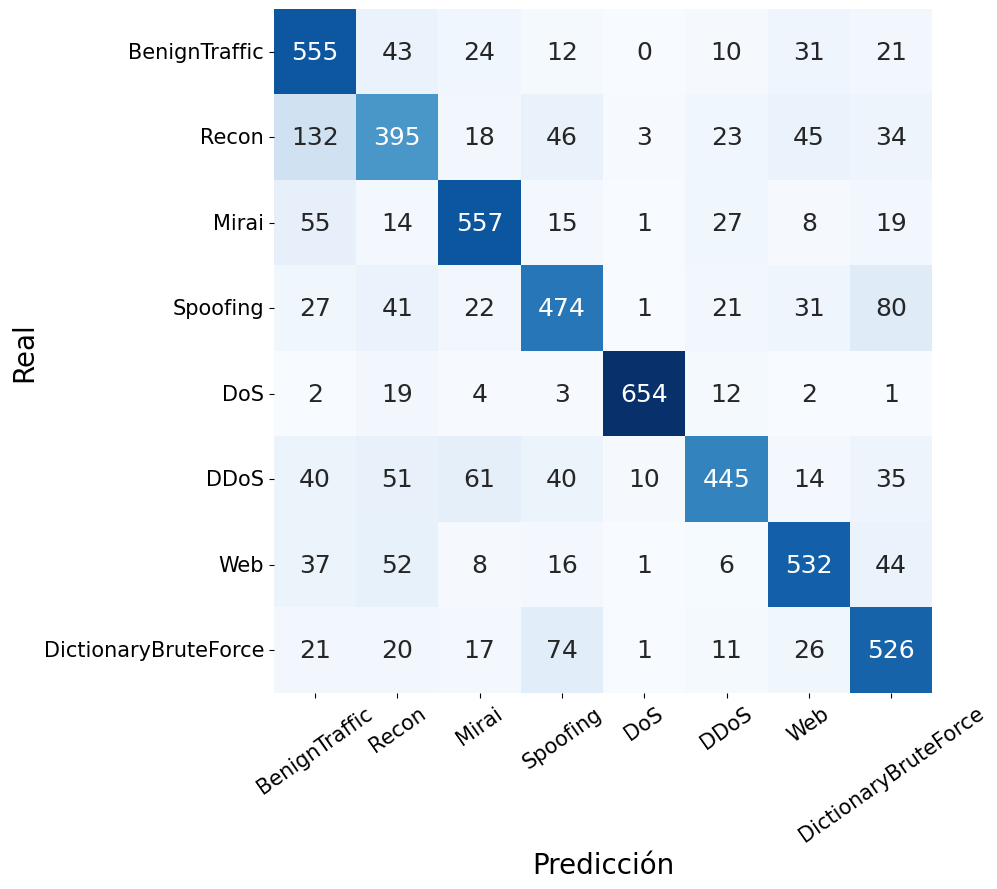

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/cm_lgbm_basico_CIC.pdf


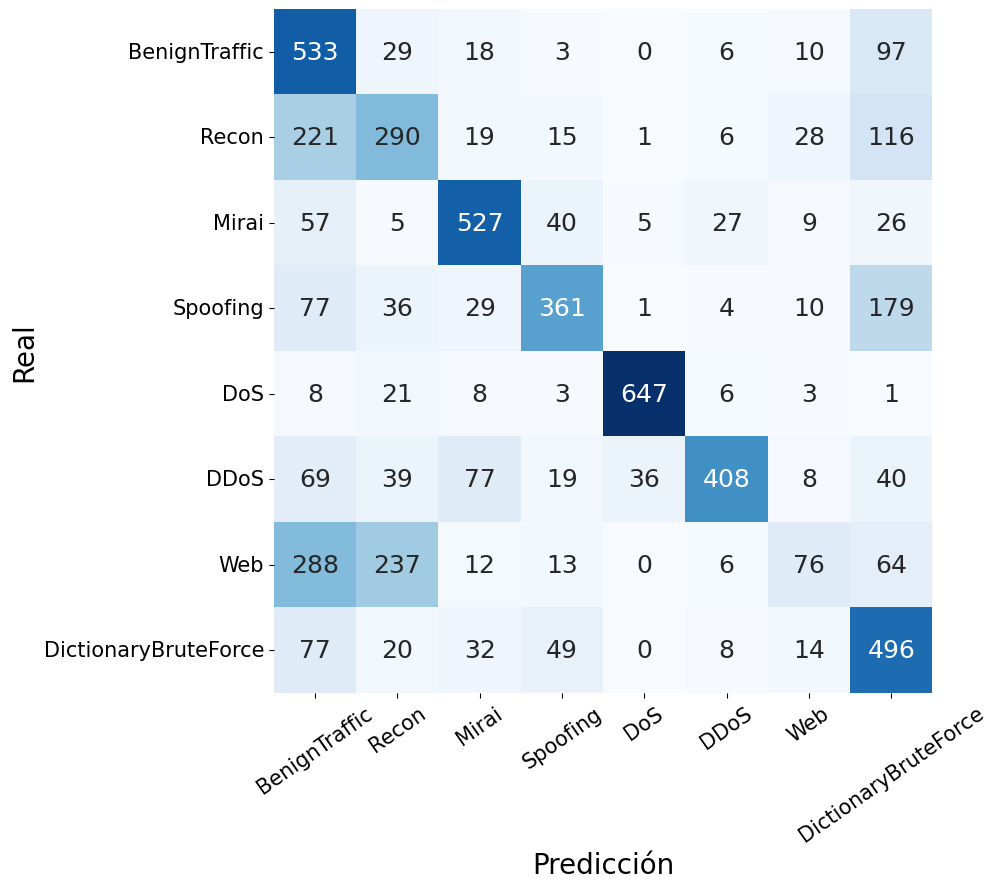

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/cm_lgbm_basico_Nemea.pdf


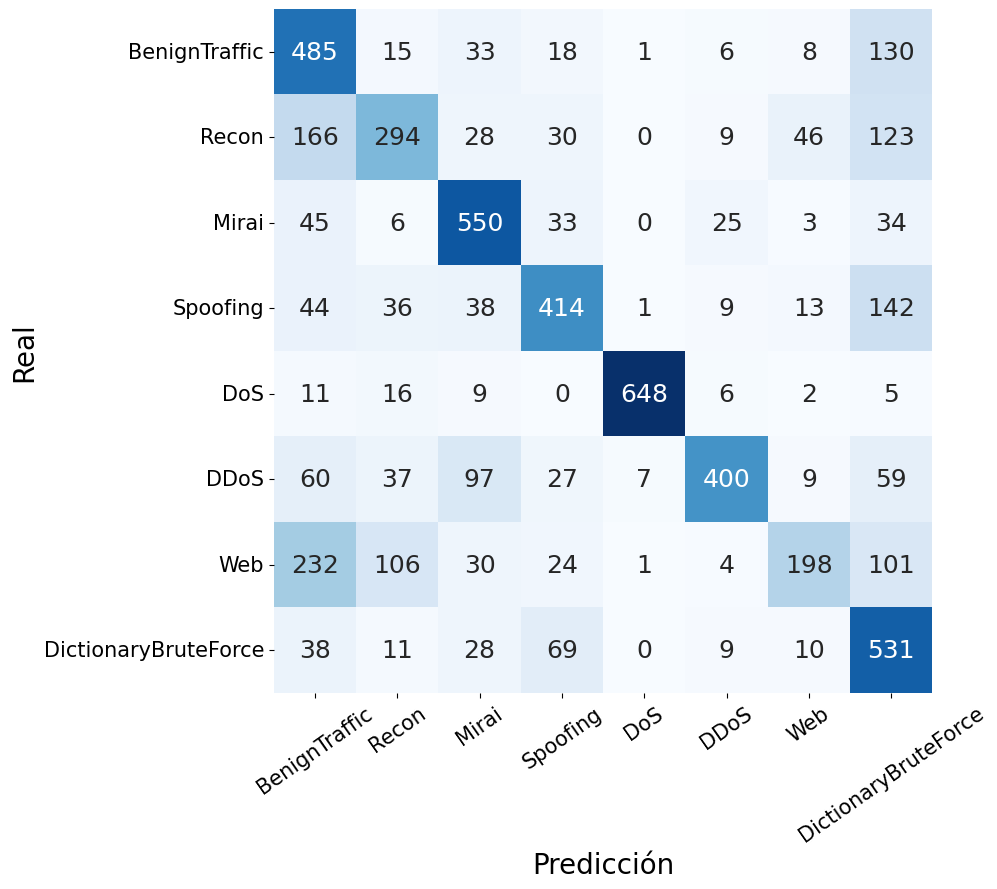

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/cm_lgbm_basico_Tstat.pdf


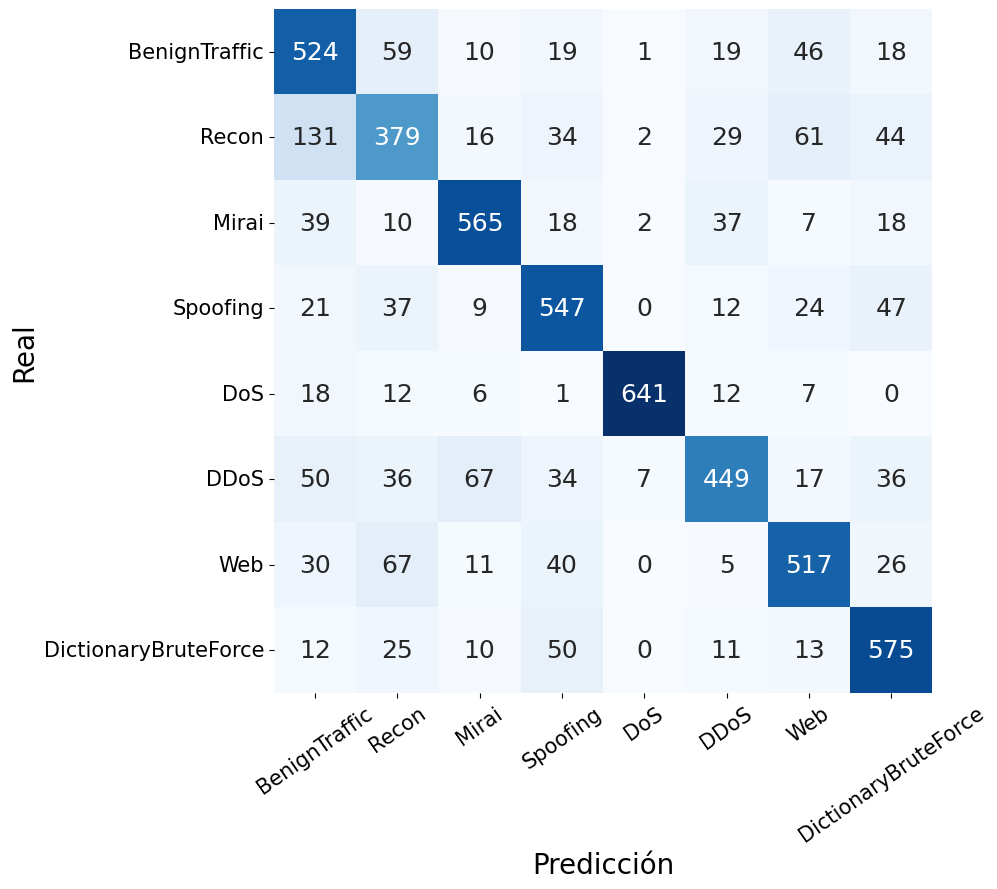

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/cm_lgbm_basico_Tshark.pdf


In [7]:
# ============================================================
# CELDA 6 — Matrices de confusión (4 PDF separados, uno por herramienta)
# ============================================================

RUTA_FIGURAS = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/Figuras')
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)

ORDEN_FIGURA = ['BenignTraffic', 'Recon', 'Mirai', 'Spoofing',
                'DoS', 'DDoS', 'Web', 'DictionaryBruteForce']

for herr in HERRAMIENTAS:
    cm = matrices_dict[herr]
    nombres = nombres_dict[herr]
    perm = [nombres.index(c) for c in ORDEN_FIGURA]
    cm_ordenada = cm[perm][:, perm]

    fig, ax = plt.subplots(figsize=(10, 9))
    sns.heatmap(cm_ordenada, annot=True, fmt='d', cmap='Blues',
                xticklabels=ORDEN_FIGURA, yticklabels=ORDEN_FIGURA,
                cbar=False, ax=ax, annot_kws={'size': 18})

    ax.set_xlabel('Predicción', fontsize=20)
    ax.set_ylabel('Real', fontsize=20)
    ax.tick_params(axis='x', rotation=35, labelsize=15)
    ax.tick_params(axis='y', rotation=0,  labelsize=15)

    plt.tight_layout()
    ruta_pdf = RUTA_FIGURAS / f'cm_lgbm_basico_{herr}.pdf'
    fig.savefig(ruta_pdf, format='pdf', bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'✓ Guardado: {ruta_pdf}')

In [8]:
# CELDA THROUGHPUT — (cambia nombre modelo en el título)
import numpy as np

BYTES_MEDIO_FLUJO = {
    'CIC':    48,
    'Nemea':  101,
    'Tstat':  51,
    'Tshark': 206
} 

print('\n' + '='*70)
print('  THROUGHPUT — LightGBM')   # ← cambiar según modelo
print('='*70)
print(f'  {"Herramienta":10s}  {"µs/muestra":12s}  {"Flujos/s":12s}  {"Throughput (Mbps)":18s}')
print(f'  {"-"*10}  {"-"*12}  {"-"*12}  {"-"*18}')

for res in resultados:
    herr = res['Herramienta']
    us_muestra = res['Pred us/muestra']
    flujos_s = 1e6 / us_muestra
    bytes_medio = BYTES_MEDIO_FLUJO[herr]
    throughput_mbps = (flujos_s * bytes_medio * 8) / 1e6
    print(f'  {herr:10s}  {us_muestra:12.1f}  {flujos_s:12.0f}  {throughput_mbps:18.1f}')


  THROUGHPUT — LightGBM
  Herramienta  µs/muestra    Flujos/s      Throughput (Mbps) 
  ----------  ------------  ------------  ------------------
  CIC                 29.8         33550                12.9
  Nemea               33.7         29694                24.0
  Tstat               28.7         34888                14.2
  Tshark              30.6         32730                53.9
